# Zomato Restaurant Data Analysis

**Dataset**: [Zomato Restaurants Data](https://www.kaggle.com/datasets/shrutimehta/zomato-restaurants-data) (Kaggle)
**Difficulty**: Beginner | **Est. time**: 2-3 weeks

This is the first project in the [data-analysts-projects-101](../README.md) series. It's an EDA
(exploratory data analysis) project: no modeling, just careful, business-relevant analysis of a
real, messy restaurant dataset.

**Architecture note**: almost all of the actual analysis below happens in SQL, not pandas. Every
query lives in [`queries.sql`](./queries.sql) as a named block, and [`db.py`](./db.py) is a ~70
line helper that loads the data into DuckDB and runs those named queries. The Streamlit dashboard
(`app.py`) calls the *exact same* queries — so nothing you see below is duplicated logic, it's the
same SQL powering both the notebook and the live app.

If you haven't already, run `python download_data.py` once to pull the dataset into `data/`.


In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import db

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# Open one DuckDB connection and reuse it for every query below — loading the
# CSV/Excel data is the expensive part, not running queries against it.
con = db.get_connection()


Matplotlib is building the font cache; this may take a moment.


## 1. Dataset overview

Before writing any analytical queries, it's worth knowing exactly what we're working with: how
many rows, what columns, and how "clean" the data actually is (Kaggle datasets almost never arrive
clean).


In [2]:
restaurants = con.execute("SELECT * FROM restaurants").df()
print(f"{len(restaurants):,} restaurants, {restaurants.shape[1]} columns\n")
restaurants.info()


9,551 restaurants, 21 columns

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  S

In [3]:
# "Aggregate rating" of 0.0 doesn't mean a 0-star review — it means the
# restaurant hasn't been rated yet. Every query below that touches rating
# filters these out (WHERE "Aggregate rating" > 0) so unrated restaurants
# don't drag the averages down artificially.
unrated = (restaurants["Aggregate rating"] == 0).sum()
print(f"{unrated:,} of {len(restaurants):,} restaurants ({unrated / len(restaurants):.1%}) are unrated")
restaurants.isna().sum().loc[lambda s: s > 0]


2,148 of 9,551 restaurants (22.5%) are unrated


Cuisines    9
dtype: int64

## 2. Geographic distribution

The dataset's name suggests India-only, but it actually spans 15 countries (Zomato used to operate
internationally before consolidating). Understanding *where* the data is concentrated matters
before drawing any conclusions from it — a "top cuisine" ranking dominated by one city isn't a
global insight.


,country,restaurant_count,avg_rating,avg_cost_for_two
0,India,8652,3.35,623.37
1,United States,434,4.03,26.15
2,United Kingdom,80,4.14,47.81
3,Brazil,60,4.11,134.67
4,UAE,60,4.23,166.42
5,South Africa,60,4.21,419.73
6,New Zealand,40,4.26,69.75
7,Turkey,34,4.30,84.85
8,Australia,24,3.66,24.08
9,Phillipines,22,4.47,1606.82


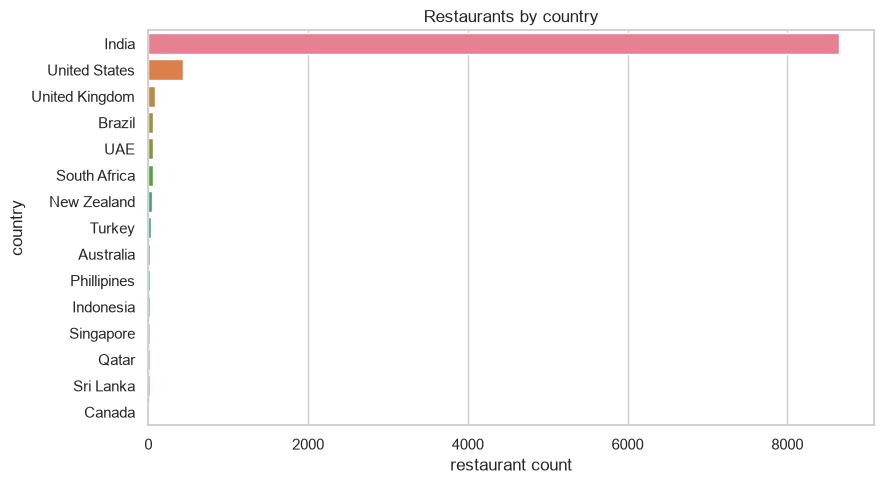

In [4]:
country_df = db.run_query("restaurants_per_country", con)
display(country_df)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(country_df, x="restaurant_count", y="country", hue="country", legend=False, ax=ax)
ax.set_title("Restaurants by country")
ax.set_xlabel("restaurant count")
plt.tight_layout()
plt.show()


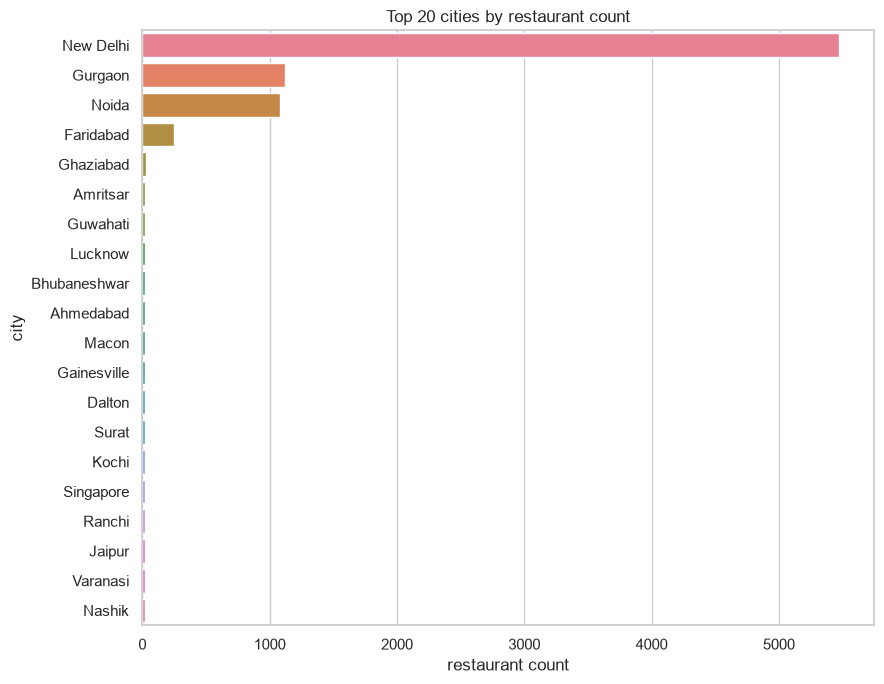

In [5]:
city_df = db.run_query("top_cities_by_count", con)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(city_df, x="restaurant_count", y="city", hue="city", legend=False, ax=ax)
ax.set_title("Top 20 cities by restaurant count")
ax.set_xlabel("restaurant count")
plt.tight_layout()
plt.show()


**Finding**: the dataset is overwhelmingly Indian (~91% of rows), and within India it's dominated
by the Delhi NCR region (New Delhi, Gurgaon, Noida together account for most Indian restaurants).
Any city- or cuisine-level conclusion should be read as "true for Delhi NCR", not "true globally" —
a caveat worth stating explicitly in any write-up of this analysis.


## 3. Cuisine popularity & quality

`Cuisines` is a single comma-separated column (e.g. `"French, Japanese, Desserts"`) — a restaurant
serving 3 cuisines needs to count toward all 3 in a "most popular cuisine" ranking. The SQL in
`queries.sql` handles this with `UNNEST(string_split(Cuisines, ','))`, which explodes one row into
one row per cuisine before aggregating. Worth knowing any time a column secretly holds a list.


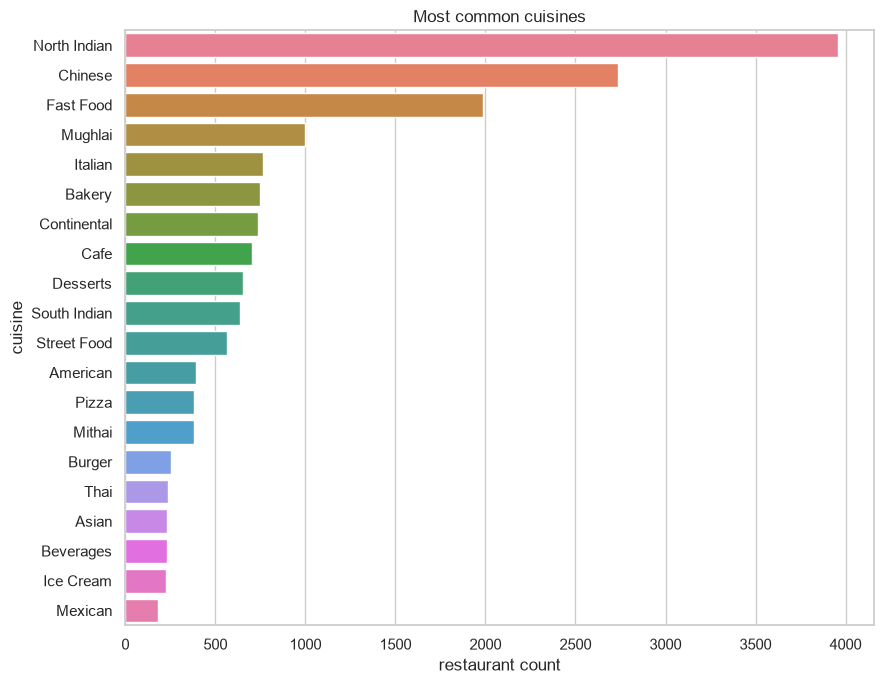

In [6]:
cuisine_count_df = db.run_query("top_cuisines_by_count", con)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(cuisine_count_df, x="restaurant_count", y="cuisine", hue="cuisine", legend=False, ax=ax)
ax.set_title("Most common cuisines")
ax.set_xlabel("restaurant count")
plt.tight_layout()
plt.show()


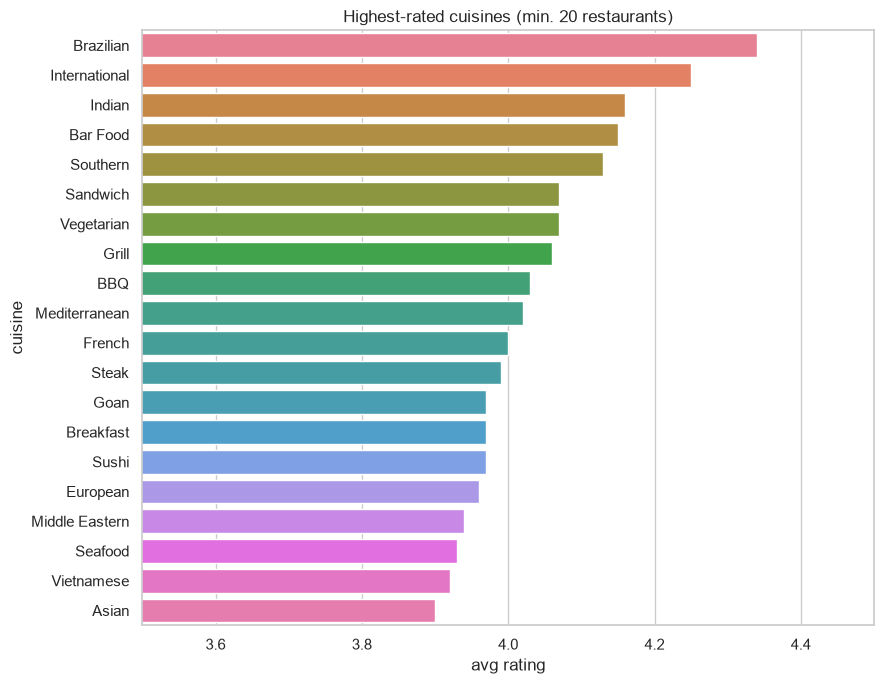

In [7]:
# HAVING COUNT(*) >= 20 in the SQL filters out cuisines with only a handful
# of restaurants, where one 5-star review would otherwise dominate the
# ranking — a small-sample-size trap worth guarding against explicitly.
cuisine_rating_df = db.run_query("top_cuisines_by_rating", con)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(cuisine_rating_df, x="avg_rating", y="cuisine", hue="cuisine", legend=False, ax=ax)
ax.set_title("Highest-rated cuisines (min. 20 restaurants)")
ax.set_xlabel("avg rating")
ax.set_xlim(3.5, 4.5)
plt.tight_layout()
plt.show()


**Finding**: North Indian, Chinese, and Fast Food are the most *common* cuisines (unsurprising,
given the Delhi-heavy sample), but they don't top the *rating* leaderboard — cuisines like
Brazilian, International, and Indian (as a standalone category, distinct from North/South Indian
splits) rate higher on average. This is the classic "popular != highest quality" split that shows
up in almost every ratings dataset.


## 4. Price vs. rating

Does spending more get you a better-rated restaurant? DuckDB's built-in `CORR()` aggregate computes
the Pearson correlation coefficient directly in SQL — no need to pull data into pandas just to call
`.corr()`.


In [8]:
corr_df = db.run_query("cost_rating_correlation", con)
display(corr_df)


,cost_vs_rating,price_range_vs_rating
0,0.077,0.403


,price_range,restaurant_count,avg_rating,avg_cost_for_two
0,1,4444,3.24,275.18
1,2,3113,3.38,596.83
2,3,1408,3.78,5177.27
3,4,586,3.89,1848.52


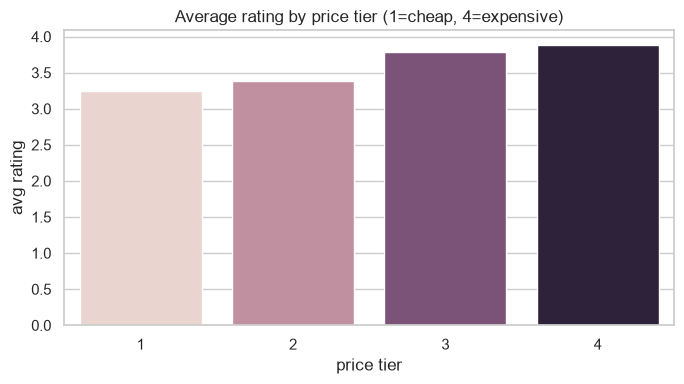

In [9]:
price_df = db.run_query("rating_by_price_range", con)
display(price_df)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(price_df, x="price_range", y="avg_rating", hue="price_range", legend=False, ax=ax)
ax.set_title("Average rating by price tier (1=cheap, 4=expensive)")
ax.set_xlabel("price tier")
ax.set_ylabel("avg rating")
plt.tight_layout()
plt.show()


**Finding**: raw cost ("Average Cost for two") barely correlates with rating (~0.08) — spending
more at a random restaurant doesn't reliably buy a better experience. But the *price tier* bucket
(1-4, Zomato's own cheap-to-expensive classification) correlates much more strongly (~0.40). The
takeaway: it's not the exact price that predicts quality, it's the market segment — cheap
street-food-tier spots and fine dining both have a rating floor/ceiling that a raw dollar amount
doesn't capture, because cost varies wildly by country and city cost-of-living.


## 5. Does online delivery / table booking correlate with rating?

Two operational features Zomato tracks per restaurant. Worth checking whether offering them
correlates with anything.


In [10]:
display(db.run_query("online_delivery_impact", con))
display(db.run_query("table_booking_impact", con))


,has_online_delivery,restaurant_count,avg_rating,avg_votes
0,No,7100,3.47,138.1
1,Yes,2451,3.38,211.3


,has_table_booking,restaurant_count,avg_rating,avg_cost_for_two
0,No,8393,3.41,1152.76
1,Yes,1158,3.59,1535.90


**Finding**: restaurants offering table booking rate noticeably higher on average (3.59 vs 3.41) —
plausibly because table booking is itself a proxy for "established, higher-end restaurant" rather
than a cause of better ratings. Online delivery shows the opposite, tiny effect — worth flagging as
correlation, not causation, in any write-up.


## 6. Best value restaurants

"Value" here = rating per dollar spent (`rating / cost_for_two`, restricted to restaurants already
rated >= 4.0 so we're not calling an empty, cheap, unrated restaurant "great value").


In [11]:
value_df = db.run_query("best_value_restaurants", con)
value_df.head(10)


,restaurant_name,city,cuisines,cost_for_two,rating,value_score
0,Shorts Burger and Shine,Cedar Rapids/Iowa City,Burger,10,4.9,490.0
1,Ingleside Village Pizza,Macon,"Pizza, Sandwich",10,4.9,490.0
2,Marukame Udon,Rest of Hawaii,Japanese,10,4.9,490.0
3,Mazzaro's Italian Market,Tampa Bay,"Italian, Deli",10,4.9,490.0
4,Oakwood Cafe,Dalton,"BBQ, Breakfast, Southern",10,4.9,490.0
5,Original Georgios Authentic Greek Food,Pensacola,Greek,10,4.7,470.0
6,Leonard's Bakery,Rest of Hawaii,NaN,10,4.7,470.0
7,Leopold's Ice Cream,Savannah,"Desserts, Sandwich, Ice Cream",10,4.6,460.0
8,Star Noodle,Rest of Hawaii,Asian,10,4.6,460.0
9,Eat at Thai,Gainesville,Thai,10,4.6,460.0


## Key takeaways

- The dataset is ~91% Indian and Delhi-NCR-heavy — any global claim needs that caveat.
- Popularity and quality diverge: North Indian/Chinese/Fast Food dominate by *count*, but
  Brazilian/International/Indian cuisines rate highest on *average*.
- Raw cost is a weak predictor of rating (r=0.08); price *tier* is a much stronger one (r=0.40) —
  segment matters more than sticker price.
- Table booking correlates with higher ratings more than online delivery does — likely a proxy for
  restaurant maturity/quality tier rather than a lever that improves ratings directly.

## Next steps
Open the interactive version of all of this — with a live city/rating filter — by running:
```bash
streamlit run app.py
```
